# **LLM Readability + RAG Retrieval-Readiness Audit (v2)**

Input: URL or DOCX (Microsoft Word Open XML)


**Quick reference**:


* **Natural Language Quality**: How clear, grammatical, and easy-to-parse the writing is (low noise, low fluff, minimal awkward phrasing.

* **Structure**: How well the document is organized with headings, lists, and predictable section patterns that make answers easy to locate.

* **Chunk Relevance**: Whether each section can stand alone as a self-contained answer “chunk” without relying on “see above/below” context.

* **User Intent Alignment**: How directly the content answers the likely questions behind the query (including common follow-ups and sub-intents.

* **Information Hierarchy**: Whether the most important answer appears earlyespecially right after the heading) instead of being buried later.

* **Context Focus & Information Density**: How tightly the text stays on-topic while packing useful facts per sentence without rambling.

* **Consistency & Specificity**: Whether terminology is consistent and the content includes concrete details numbers, entities, thresholds, examples rather than vague statements.

* **Co-occurrence Signals**: Whether important concepts repeatedly appear together in meaningful patterns (a sign of strong topical cohesion and retrievability).







In [ ]:
# =========================
# 0) INSTALL
# =========================
!pip -q install requests beautifulsoup4 readability-lxml lxml_html_clean python-docx pandas numpy matplotlib networkx scikit-learn
!pip -q install sentence-transformers

# Optional: nicer BM25 implementation (we also include a fallback pure-Python BM25)
# !pip -q install rank-bm25

import re
import math
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from bs4 import BeautifulSoup
from readability.readability import Document
from docx import Document as DocxDocument
from collections import Counter, defaultdict
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity

# Dense retrieval (Sentence Transformers)
from sentence_transformers import SentenceTransformer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 5.6 MB/s eta 0:00:00


In [ ]:
# =========================
# 1) CONFIG
# =========================
# INPUT_MODE = "url" or "docx"
INPUT_MODE = "url"

# If URL mode:
INPUT_URL = "https://www.eflexsystems.com/lean-manufacturing-blog/how-to-improve-first-pass-yield"

# If DOCX mode:
INPUT_DOCX_PATH = "/content/your_file.docx"

# Query set for retrieval-readiness / intent match (fan-out queries)
# Add 10-50 queries for best signal.
FANOUT_QUERIES = [
    "first pass yield formula",
     "what is a good first pass yield percentage",
     "first pass yield calculator",
     "first pass yield chart",
     "first pass yield vs rolled througput yield",
]

# Toggle dense retrieval (embeddings)
USE_DENSE_RETRIEVAL = True

# Toggle co-occurrence graph visualization
SHOW_COOCCURRENCE_GRAPH = True

# Weighting for final overall score
WEIGHTS = {
    "Chunk relevance": 0.16,
    "Structuring": 0.12,
    "Information hierarchy": 0.10,
    "Language quality": 0.08,
    "Consistency & specificity": 0.10,
    "Context focus & info density": 0.14,
    "Co-occurrence signals": 0.10,
    "Hybrid intent match": 0.20,  # highest weight in retrieval-oriented audits
}

# Heuristics and lexical controls
BAD_COHESION_PHRASES = [
    "as mentioned above", "as mentioned earlier", "as noted above", "see above",
    "as mentioned below", "see below", "we will discuss", "discussed later",
    "in the next section", "in the previous section", "this table", "the table above"
]
QUESTION_HEADING_RE = re.compile(r"^(what|why|when|how|who|where|which)\b", re.I)

STOPWORDS = {
    "the","and","for","that","with","this","from","your","have","will","into","about","they","their",
    "what","when","where","which","while","there","these","those","than","then","them","been","being",
    "are","was","were","is","am","be","to","of","in","on","by","as","at","an","a","or","if","it","its",
    "you","we","our","can","could","should","would","may","might","not","do","does","did","done","using",
    "use","used","also","more","most","less","such","very","just","only","over","under","between","within",
    "how","why","who","where","which","what","when"
}

# BM25 parameters
BM25_K1 = 1.5
BM25_B = 0.75

# Co-occurrence parameters
COOC_WINDOW_SIZE = 8
COOC_MIN_TOKEN_LEN = 4
COOC_TOP_K = 20

# Chunk / section diagnostics
LONG_SECTION_CHAR_THRESHOLD = 1200
FIRST_SENTENCE_IDEAL_MAX_CHARS = 400

In [ ]:
# =========================
# 2) TEXT UTILITIES
# =========================
def clean_text(s: str) -> str:
    s = s or ""
    s = s.replace("\xa0", " ")
    s = re.sub(r"\s+", " ", s)
    return s.strip()

def split_sentences(text: str):
    return [s.strip() for s in re.split(r"(?<=[.!?])\s+", text or "") if s.strip()]

def tokenize(text: str):
    return re.findall(r"\b[a-zA-Z][a-zA-Z\-']+\b", (text or "").lower())

def content_tokens(text: str):
    toks = [t for t in tokenize(text) if len(t) >= 3]
    return [t for t in toks if t not in STOPWORDS]

def safe_div(a, b, default=0.0):
    return a / b if b else default


In [ ]:
# =========================
# 3) INPUT LOADERS (URL / DOCX)
# =========================
def extract_sections_from_html(soup: BeautifulSoup):
    headings = soup.find_all(["h1", "h2", "h3", "h4"])
    if not headings:
        return []

    sections = []
    for h in headings:
        title = clean_text(h.get_text(" "))
        content_nodes = []
        for sib in h.next_siblings:
            if getattr(sib, "name", None) in ["h1", "h2", "h3", "h4"]:
                break
            if getattr(sib, "name", None) in ["p", "ul", "ol", "table", "blockquote"]:
                content_nodes.append(sib)

        raw = "".join(str(n) for n in content_nodes)
        content_text = clean_text(BeautifulSoup(raw, "lxml").get_text(" "))
        if content_text:
            sections.append({
                "heading_text": title,
                "content_text": content_text
            })
    return sections

def load_from_url(url: str):
    r = requests.get(url, timeout=20, headers={"User-Agent": "Mozilla/5.0"})
    r.raise_for_status()
    html = r.text

    main_html = Document(html).summary(html_partial=True)
    soup = BeautifulSoup(main_html, "lxml")
    raw_text = clean_text(soup.get_text(" "))

    sections = extract_sections_from_html(soup)
    if not sections:
        sections = [{"heading_text": None, "content_text": raw_text}]

    return raw_text, main_html, sections

def load_from_docx(path: str):
    doc = DocxDocument(path)
    paragraphs = doc.paragraphs

    sections = []
    current_heading = None
    buf = []
    all_text_parts = []

    def flush():
        nonlocal buf, current_heading
        content = clean_text(" ".join(buf))
        if content:
            sections.append({"heading_text": current_heading, "content_text": content})
        buf = []

    for p in paragraphs:
        txt = clean_text(p.text)
        if not txt:
            continue
        all_text_parts.append(txt)

        style_name = (p.style.name or "").lower() if p.style else ""
        is_heading = style_name.startswith("heading") or style_name in {"title", "subtitle"}

        if is_heading:
            flush()
            current_heading = txt
        else:
            buf.append(txt)

    flush()
    raw_text = clean_text(" ".join(all_text_parts))
    if not sections:
        sections = [{"heading_text": None, "content_text": raw_text}]

    return raw_text, None, sections

def load_input(mode, url=None, docx_path=None):
    mode = (mode or "").lower().strip()
    if mode == "url":
        if not url:
            raise ValueError("INPUT_URL is required when INPUT_MODE='url'")
        return load_from_url(url)
    elif mode == "docx":
        if not docx_path:
            raise ValueError("INPUT_DOCX_PATH is required when INPUT_MODE='docx'")
        return load_from_docx(docx_path)
    else:
        raise ValueError("INPUT_MODE must be 'url' or 'docx'")

In [ ]:
# =========================
# 4) SECTION / CHUNK HELPERS
# =========================
def build_chunk_records(sections):
    rows = []
    for i, s in enumerate(sections):
        heading = s.get("heading_text") or ""
        content = s.get("content_text") or ""
        chunk_text = clean_text((heading + " " + content).strip())
        first_sentence = split_sentences(content)[0] if split_sentences(content) else ""
        answer_first = bool(
            re.search(r"\b(is|are|means|refers to|requires|includes|takes|costs)\b", first_sentence, re.I)
            or re.search(r"\d", first_sentence)
        )
        context_dependency_hits = sum(1 for p in BAD_COHESION_PHRASES if p in content.lower())

        rows.append({
            "chunk_id": i,
            "heading": heading,
            "content": content,
            "chunk_text": chunk_text,
            "chunk_chars": len(content),
            "first_sentence": first_sentence,
            "first_sentence_chars": len(first_sentence),
            "answer_in_first_sentence": answer_first,
            "context_dependency_hits": context_dependency_hits,
        })
    return pd.DataFrame(rows)

In [ ]:
# =========================
# 5) CORE READABILITY DIAGNOSTICS
# =========================
def score_structuring(sections):
    headings = [s["heading_text"] for s in sections if s.get("heading_text")]
    total_heads = len(headings)
    q_heads = sum(1 for h in headings if QUESTION_HEADING_RE.search(h or ""))
    q_ratio = safe_div(q_heads, total_heads, 0.0)

    text_join = "\n".join(s.get("content_text","") for s in sections)
    bullet_hits = len(re.findall(r"(^|\n)\s*[-•*]\s+", text_join))
    numbered_hits = len(re.findall(r"(^|\n)\s*\d+\.\s+", text_join))
    step_words = len(re.findall(r"\b(step|steps|first|second|third|process|workflow)\b", text_join, flags=re.I))

    score = 0
    score += 30 if total_heads >= 8 else 20 if total_heads >= 4 else 10 if total_heads >= 1 else 0
    score += min(25, q_ratio * 25)
    score += min(25, (bullet_hits + numbered_hits) * 2 + step_words * 0.5)
    score += 20 if total_heads >= 12 else 10 if total_heads >= 6 else 0
    return float(np.clip(score, 0, 100))

def score_chunk_relevance(sections):
    penalties = 0
    answer_first = 0
    short_first = 0

    for s in sections:
        text = s.get("content_text","")
        low = text.lower()
        for phrase in BAD_COHESION_PHRASES:
            if phrase in low:
                penalties += 1

        sents = split_sentences(text)
        first_sentence = sents[0] if sents else ""

        if re.search(r"\b(is|are|means|refers to|requires|includes|takes|costs)\b", first_sentence, re.I) or re.search(r"\d", first_sentence):
            answer_first += 1
        if len(first_sentence) <= FIRST_SENTENCE_IDEAL_MAX_CHARS:
            short_first += 1

    n = max(1, len(sections))
    score = 100
    score -= min(45, penalties * 6)
    score += (answer_first / n) * 10
    score += (short_first / n) * 10
    return float(np.clip(score, 0, 100))

def score_information_hierarchy(sections):
    hits = 0
    for s in sections:
        text = s.get("content_text","")
        sents = split_sentences(text)
        first_sentence = sents[0] if sents else ""
        if re.search(r"\d", first_sentence) or re.search(r"\b(is|are|means|refers to|requires|includes|takes|costs)\b", first_sentence, re.I):
            hits += 1
    ratio = hits / max(1, len(sections))
    return float(np.clip(ratio * 100, 0, 100))

def score_language_quality_offline(doc_text):
    sentences = split_sentences(doc_text)
    if not sentences:
        return 0.0

    words_per_sentence = [len(re.findall(r"\b[\w'-]+\b", s)) for s in sentences]
    avg_wps = float(np.mean(words_per_sentence))
    long_sent_share = float(np.mean([wps > 35 for wps in words_per_sentence]))

    toks = [t for t in tokenize(doc_text) if t not in STOPWORDS]
    top_mass = float(pd.Series(toks).value_counts().head(30).sum() / (len(toks) or 1))

    artifact_ratio = len(re.findall(r"[|_/\\]{2,}|[^\x00-\x7F]{2,}", doc_text)) / max(1, len(sentences))

    score = 100
    score -= min(25, max(0, avg_wps - 24) * 1.2)
    score -= min(20, long_sent_share * 40)
    score -= min(20, max(0, top_mass - 0.18) * 120)
    score -= min(10, artifact_ratio * 10)
    return float(np.clip(score, 0, 100))

def score_consistency_specificity(doc_text):
    words = max(1, len(re.findall(r"\b[\w'-]+\b", doc_text)))
    numbers = len(re.findall(r"\b\d+(\.\d+)?\b", doc_text))
    perc = len(re.findall(r"\b\d+(\.\d+)?\s?%\b", doc_text))
    money = len(re.findall(r"[$€£]\s?\d", doc_text))
    dates = len(re.findall(r"\b(19|20)\d{2}\b", doc_text))

    answer_type_density = (numbers + 2*perc + 2*money + dates) / (words / 1000.0)

    toks = [t for t in content_tokens(doc_text) if len(t) >= 4]
    top_mass = float(pd.Series(toks).value_counts().head(25).sum() / (len(toks) or 1))

    score = 50
    score += min(40, answer_type_density * 2.0)
    score += min(10, top_mass * 20)
    return float(np.clip(score, 0, 100))

def score_context_focus_info_density(sections, doc_text):
    # A) Context Focus: section topical concentration
    section_focus_scores = []
    for s in sections:
        toks = content_tokens(s.get("content_text",""))
        if len(toks) < 10:
            continue
        vc = pd.Series(toks).value_counts()
        top5_mass = float(vc.head(5).sum() / len(toks))
        unique_ratio = float(len(vc) / len(toks))
        focus = 70 * top5_mass + 30 * min(1.0, unique_ratio / 0.6)
        section_focus_scores.append(focus)

    if section_focus_scores:
        context_focus = float(np.mean(section_focus_scores))
        variance_penalty = min(15, float(np.std(section_focus_scores)) * 0.4)
        context_focus = float(np.clip(context_focus - variance_penalty, 0, 100))
    else:
        context_focus = 50.0

    # B) Information Density: sentence signal richness without sprawl
    sentences = split_sentences(doc_text)
    if not sentences:
        info_density = 0.0
    else:
        sentence_scores = []
        for sent in sentences:
            toks = content_tokens(sent)
            if not toks:
                continue
            numbers = len(re.findall(r"\b\d+(\.\d+)?\b", sent))
            title_case = len(re.findall(r"\b[A-Z][a-z]+\b", sent))
            long_terms = len(re.findall(r"\b[a-z]{8,}\b", sent.lower()))
            unique_ratio = len(set(toks)) / max(1, len(toks))
            sent_len = len(toks)

            raw = (numbers * 2.0) + (title_case * 1.0) + (long_terms * 0.8) + (unique_ratio * 8.0)

            if sent_len < 6:
                raw *= 0.7
            elif sent_len > 40:
                raw *= 0.8

            sentence_scores.append(raw)

        info_density = float(np.clip(np.mean(sentence_scores) * 6.0, 0, 100)) if sentence_scores else 40.0

    combined = 0.55 * context_focus + 0.45 * info_density
    return float(np.clip(combined, 0, 100)), {
        "context_focus": context_focus,
        "information_density": info_density
    }

In [ ]:
# =========================
# 6) CO-OCCURRENCE SIGNALS (with optional PMI)
# =========================
def compute_cooccurrence_signals(doc_text, sections, window_size=8, min_token_len=4, top_k=20, compute_pmi=True):
    toks = [t for t in content_tokens(doc_text) if len(t) >= min_token_len]
    if len(toks) < 20:
        empty_df = pd.DataFrame(columns=["term_a","term_b","count","pmi"])
        return 0.0, empty_df, {"note": "Not enough tokens for co-occurrence analysis"}, None

    pair_counts = Counter()
    term_counts = Counter(toks)
    total_windows = 0

    # Sliding-window co-occurrence
    for i in range(len(toks)):
        window = toks[i:i+window_size]
        if len(window) < 2:
            continue
        total_windows += 1
        uniq = sorted(set(window))
        for a, b in combinations(uniq, 2):
            pair_counts[(a, b)] += 1

    if not pair_counts:
        empty_df = pd.DataFrame(columns=["term_a","term_b","count","pmi"])
        return 0.0, empty_df, {"note": "No co-occurring pairs found"}, None

    # Optional PMI (Pointwise Mutual Information)
    pmi_map = {}
    if compute_pmi:
        N = max(1, len(toks))
        total_pair_events = max(1, sum(pair_counts.values()))
        for (a, b), c_ab in pair_counts.items():
            p_a = term_counts[a] / N
            p_b = term_counts[b] / N
            p_ab = c_ab / total_pair_events
            if p_a > 0 and p_b > 0 and p_ab > 0:
                pmi = math.log2(p_ab / (p_a * p_b))
            else:
                pmi = 0.0
            pmi_map[(a, b)] = pmi

    top_pairs = pair_counts.most_common(top_k)
    top_df = pd.DataFrame([
        (a, b, c, float(pmi_map.get((a,b), np.nan)))
        for (a, b), c in top_pairs
    ], columns=["term_a", "term_b", "count", "pmi"])

    # Pair concentration / support
    total_pair_events = sum(pair_counts.values())
    top_pair_mass = sum(c for _, c in top_pairs) / max(1, total_pair_events)
    avg_top_pair_count = float(np.mean([c for _, c in top_pairs])) if top_pairs else 0.0

    # Section spread signal
    section_pair_presence = Counter()
    for s in sections:
        stoks = [t for t in content_tokens(s.get("content_text","")) if len(t) >= min_token_len]
        if len(stoks) < 5:
            continue
        spairs = set()
        for i in range(len(stoks)):
            w = stoks[i:i+window_size]
            uniq = sorted(set(w))
            for a, b in combinations(uniq, 2):
                spairs.add((a, b))
        for p in spairs:
            section_pair_presence[p] += 1

    if len(section_pair_presence) > 0 and top_pairs:
        spread_vals = [section_pair_presence.get(pair, 0) for pair, _ in top_pairs]
        avg_section_spread = float(np.mean(spread_vals))
        max_sections = max(1, len(sections))
        spread_norm = min(1.0, (avg_section_spread / max_sections) * 3.0)
    else:
        avg_section_spread = 0.0
        spread_norm = 0.0

    # PMI quality on top pairs (positive PMI often signals stronger semantic associations)
    if compute_pmi and len(top_df) > 0 and top_df["pmi"].notna().any():
        mean_top_pmi = float(np.nanmean(top_df["pmi"]))
        pmi_component = np.clip((mean_top_pmi + 2) * 8, 0, 20)  # heuristic normalization
    else:
        mean_top_pmi = np.nan
        pmi_component = 0.0

    # Co-occurrence score
    score = 0
    score += min(40, avg_top_pair_count * 2.2)
    score += min(25, top_pair_mass * 120)
    score += min(20, spread_norm * 20)
    score += pmi_component
    score = float(np.clip(score, 0, 100))

    diagnostics = {
        "unique_tokens": len(set(toks)),
        "total_tokens_used": len(toks),
        "unique_pairs": len(pair_counts),
        "top_pair_mass": float(top_pair_mass),
        "avg_top_pair_count": float(avg_top_pair_count),
        "avg_top_pair_section_spread": float(avg_section_spread),
        "mean_top_pmi": float(mean_top_pmi) if not np.isnan(mean_top_pmi) else None,
        "window_size": window_size,
        "total_windows": total_windows,
    }

    # Build graph object (top pairs only) for plotting
    G = nx.Graph()
    for _, row in top_df.iterrows():
        G.add_edge(row["term_a"], row["term_b"], weight=float(row["count"]), pmi=float(row["pmi"]) if pd.notna(row["pmi"]) else 0.0)

    return score, top_df, diagnostics, G


In [ ]:
# =========================
# 7) SPARSE RETRIEVAL (BM25) + DENSE RETRIEVAL + HYBRID
# =========================
class SimpleBM25:
    """
    Pure-Python BM25 (Best Matching 25) for chunk retrieval.
    Good enough for Colab and easy to inspect.
    """
    def __init__(self, corpus_tokenized, k1=1.5, b=0.75):
        self.corpus = corpus_tokenized
        self.k1 = k1
        self.b = b
        self.N = len(corpus_tokenized)
        self.doc_lens = [len(doc) for doc in corpus_tokenized]
        self.avgdl = np.mean(self.doc_lens) if self.doc_lens else 0.0

        self.tf = []
        self.df = Counter()

        for doc in corpus_tokenized:
            c = Counter(doc)
            self.tf.append(c)
            for term in c.keys():
                self.df[term] += 1

        self.idf = {}
        for term, df_t in self.df.items():
            # BM25 IDF variant
            self.idf[term] = math.log(1 + (self.N - df_t + 0.5) / (df_t + 0.5))

    def score_query(self, query_tokens):
        scores = np.zeros(self.N, dtype=float)
        if self.N == 0:
            return scores

        for i, doc_tf in enumerate(self.tf):
            dl = self.doc_lens[i]
            denom_norm = self.k1 * (1 - self.b + self.b * (dl / self.avgdl)) if self.avgdl > 0 else self.k1
            score = 0.0
            for t in query_tokens:
                if t not in doc_tf:
                    continue
                tf_td = doc_tf[t]
                idf_t = self.idf.get(t, 0.0)
                numer = tf_td * (self.k1 + 1)
                denom = tf_td + denom_norm
                score += idf_t * (numer / denom)
            scores[i] = score
        return scores

def build_retrieval_chunks(chunk_df):
    chunk_texts = chunk_df["chunk_text"].fillna("").tolist()
    tokenized = [content_tokens(t) for t in chunk_texts]
    return chunk_texts, tokenized

def compute_sparse_retrieval_coverage(chunk_df, queries):
    if not queries:
        return 50.0, pd.DataFrame(), {"note": "No FANOUT_QUERIES provided"}

    chunk_texts, tokenized_chunks = build_retrieval_chunks(chunk_df)
    bm25 = SimpleBM25(tokenized_chunks, k1=BM25_K1, b=BM25_B)

    rows = []
    best_scores = []

    for q in queries:
        q_tokens = content_tokens(q)
        scores = bm25.score_query(q_tokens)
        if len(scores) == 0:
            continue
        best_idx = int(np.argmax(scores))
        best_score = float(scores[best_idx])
        best_scores.append(best_score)
        rows.append({
            "query": q,
            "best_chunk_id": int(chunk_df.iloc[best_idx]["chunk_id"]),
            "best_heading": chunk_df.iloc[best_idx]["heading"],
            "bm25_best_score": best_score
        })

    per_query_df = pd.DataFrame(rows)

    if len(best_scores) == 0:
        return 50.0, per_query_df, {"note": "Queries produced no sparse matches"}

    # Normalize BM25 scores with robust scaling
    arr = np.array(best_scores, dtype=float)
    p90 = np.percentile(arr, 90) if len(arr) > 1 else max(arr[0], 1.0)
    norm = np.clip(arr / max(p90, 1e-6), 0, 1)
    mean_norm = float(np.mean(norm))
    weak_share = float(np.mean(norm < 0.25))

    score = mean_norm * 100
    score -= min(20, weak_share * 40)
    score = float(np.clip(score, 0, 100))

    diagnostics = {
        "mean_normalized_bm25": mean_norm,
        "weak_query_share_sparse(<0.25 norm)": weak_share,
        "n_queries_scored": len(best_scores)
    }
    return score, per_query_df, diagnostics

def compute_dense_retrieval_coverage(chunk_df, queries, model_name="sentence-transformers/all-MiniLM-L6-v2"):
    if not queries:
        return 50.0, pd.DataFrame(), {"note": "No FANOUT_QUERIES provided"}

    chunk_texts = chunk_df["chunk_text"].fillna("").tolist()
    if len(chunk_texts) == 0:
        return 0.0, pd.DataFrame(), {"note": "No chunks available"}

    model = SentenceTransformer(model_name)
    q_emb = model.encode(queries, normalize_embeddings=True)
    c_emb = model.encode(chunk_texts, normalize_embeddings=True)
    sims = cosine_similarity(q_emb, c_emb)  # shape: [Q x C]

    rows = []
    best_sims = []
    for qi, q in enumerate(queries):
        best_idx = int(np.argmax(sims[qi]))
        best_sim = float(sims[qi, best_idx])
        best_sims.append(best_sim)
        rows.append({
            "query": q,
            "best_chunk_id": int(chunk_df.iloc[best_idx]["chunk_id"]),
            "best_heading": chunk_df.iloc[best_idx]["heading"],
            "dense_best_similarity": best_sim
        })

    per_query_df = pd.DataFrame(rows)

    arr = np.array(best_sims, dtype=float)
    mean_best = float(np.mean(arr))
    weak_share = float(np.mean(arr < 0.35))

    score = mean_best * 100
    score -= min(25, weak_share * 50)
    score = float(np.clip(score, 0, 100))

    diagnostics = {
        "mean_best_similarity": mean_best,
        "weak_query_share_dense(<0.35)": weak_share,
        "n_queries_scored": len(best_sims)
    }
    return score, per_query_df, diagnostics

def compute_hybrid_intent_match(chunk_df, sparse_score, dense_score=None):
    """
    Hybrid intent score blends:
    - sparse retrieval (BM25) lexical answerability
    - dense retrieval semantic answerability
    - chunk answer-first behavior / self-containedness
    """
    answer_first_ratio = float(chunk_df["answer_in_first_sentence"].mean()) if len(chunk_df) else 0.0
    context_dep_mean = float(chunk_df["context_dependency_hits"].mean()) if len(chunk_df) else 0.0
    context_penalty = min(15, context_dep_mean * 8)

    if dense_score is None:
        # sparse-only fallback
        hybrid = 0.75 * sparse_score + 0.25 * (answer_first_ratio * 100)
    else:
        hybrid = 0.45 * sparse_score + 0.40 * dense_score + 0.15 * (answer_first_ratio * 100)

    hybrid -= context_penalty
    return float(np.clip(hybrid, 0, 100)), {
        "answer_first_ratio": answer_first_ratio,
        "avg_context_dependency_hits_per_chunk": context_dep_mean,
        "context_penalty_applied": context_penalty
    }

In [ ]:

# =========================
# 8) VISUALIZATION HELPERS
# =========================
def plot_spider_chart(subscores: dict, overall: float,
                      title="LLM Readability Diagnostics Spider Graph"):
    labels = list(subscores.keys())
    values = [subscores[k] for k in labels]
    angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()

    values_loop = values + [values[0]]
    angles_loop = angles + [angles[0]]

    fig = plt.figure(figsize=(10, 14))
    ax = fig.add_subplot(111, polar=True)

    ax.plot(angles_loop, values_loop, linewidth=2)
    ax.fill(angles_loop, values_loop, alpha=0.15)

    ax.set_thetagrids(np.degrees(angles), labels)
    ax.set_ylim(0, 100)

    ax.set_title(f"{title} (Overall: {overall:.1f}/100)", pad=30)

    # 🔧 Shrink the axes box to create breathing room for title/ticks
    ax.set_position([0.12, 0.08, 0.76, 0.76])  # [left, bottom, width, height]

    plt.show()

def plot_cooccurrence_graph(G, max_nodes=20, top_edges=40,
                            min_size=250, max_size=1400,
                            k=1.2, spread=1.15, label_offset=0.02):
    if G is None or G.number_of_nodes() == 0:
        print("No co-occurrence graph to plot.")
        return

    # Keep strongest edges only
    edges_sorted = sorted(G.edges(data=True),
                          key=lambda x: x[2].get("weight", 0),
                          reverse=True)
    H = nx.Graph()
    for u, v, d in edges_sorted[:top_edges]:
        H.add_edge(u, v, **d)

    # Limit node count (take nodes by weighted degree)
    if H.number_of_nodes() > max_nodes:
        weighted_degree = sorted(H.degree(weight="weight"), key=lambda x: x[1], reverse=True)
        keep = set([n for n, _ in weighted_degree[:max_nodes]])
        H = H.subgraph(keep).copy()

    # --- Layout: increase k to spread nodes; optionally scale positions ---
    pos = nx.spring_layout(H, seed=42, k=k, iterations=100)
    pos = {n: (xy[0] * spread, xy[1] * spread) for n, xy in pos.items()}

    # --- Node sizes: log-compress + clamp to avoid huge bubbles ---
    deg = np.array([H.degree(n, weight="weight") for n in H.nodes()], dtype=float)
    deg = np.maximum(deg, 0.0)

    # log1p compresses big values while preserving ordering
    s = np.log1p(deg)

    if s.max() > s.min():
        s_norm = (s - s.min()) / (s.max() - s.min())
    else:
        s_norm = np.zeros_like(s)

    node_sizes = (min_size + s_norm * (max_size - min_size)).tolist()

    # --- Edge widths: also compress a bit (optional) ---
    w = np.array([d.get("weight", 1.0) for _, _, d in H.edges(data=True)], dtype=float)
    w = np.maximum(w, 0.0)
    edge_widths = (0.6 + 2.2 * (w / (w.max() if w.max() else 1.0))**0.6).tolist()

    plt.figure(figsize=(15, 8))

    nx.draw_networkx_nodes(H, pos, node_size=node_sizes, alpha=0.85)
    nx.draw_networkx_edges(H, pos, width=edge_widths, alpha=0.35)

    # Labels slightly offset so they don't sit dead-center on bubbles
    pos_labels = {n: (pos[n][0], pos[n][1] + label_offset) for n in H.nodes()}
    nx.draw_networkx_labels(H, pos_labels, font_size=10)

    plt.title("Top Co-occurrence Network (term pairs)")
    plt.axis("off")
    plt.show()

In [ ]:
# =========================
# 9) MAIN PIPELINE
# =========================
raw_text, raw_html, sections = load_input(INPUT_MODE, INPUT_URL, INPUT_DOCX_PATH)
chunk_df = build_chunk_records(sections)

# Base diagnostics
structuring = score_structuring(sections)
chunk_relevance = score_chunk_relevance(sections)
info_hierarchy = score_information_hierarchy(sections)
language_quality = score_language_quality_offline(raw_text)
consistency_specificity = score_consistency_specificity(raw_text)
context_focus_density, cfd_diag = score_context_focus_info_density(sections, raw_text)

# Co-occurrence
coocc_score, coocc_top_pairs_df, coocc_diag, coocc_graph = compute_cooccurrence_signals(
    raw_text, sections,
    window_size=COOC_WINDOW_SIZE,
    min_token_len=COOC_MIN_TOKEN_LEN,
    top_k=COOC_TOP_K,
    compute_pmi=True
)

# Sparse retrieval (BM25)
sparse_score, sparse_per_query_df, sparse_diag = compute_sparse_retrieval_coverage(chunk_df, FANOUT_QUERIES)

# Dense retrieval (embeddings)
dense_score = None
dense_per_query_df = pd.DataFrame()
dense_diag = {"note": "Dense retrieval disabled"}
if USE_DENSE_RETRIEVAL and len(FANOUT_QUERIES) > 0:
    try:
        dense_score, dense_per_query_df, dense_diag = compute_dense_retrieval_coverage(chunk_df, FANOUT_QUERIES)
    except Exception as e:
        dense_score = None
        dense_diag = {"error": str(e)}

# Hybrid intent match
hybrid_intent, hybrid_diag = compute_hybrid_intent_match(chunk_df, sparse_score, dense_score)

# Subscores
subscores = {
    "Chunk relevance": chunk_relevance,
    "Structuring": structuring,
    "Information hierarchy": info_hierarchy,
    "Language quality": language_quality,
    "Consistency & specificity": consistency_specificity,
    "Context focus & info density": context_focus_density,
    "Co-occurrence signals": coocc_score,
    "Hybrid intent match": hybrid_intent,
}

# Weighted overall
overall = float(sum(subscores[k] * WEIGHTS[k] for k in subscores if k in WEIGHTS) / sum(WEIGHTS.values()))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

LLM READABILITY + RAG RETRIEVAL-READINESS AUDIT (v2)
Input mode: url
URL: https://www.eflexsystems.com/lean-manufacturing-blog/how-to-improve-first-pass-yield
Sections detected: 1
Chunks built: 1
Overall score (weighted): 58.1/100

Diagnostic Scores


,Diagnostic,Score
0,Chunk relevance,100.000000
6,Co-occurrence signals,87.852642
3,Language quality,76.148148
5,Context focus & info density,60.015124
4,Consistency & specificity,57.803618
7,Hybrid intent match,55.803854
1,Structuring,16.000000
2,Information hierarchy,0.000000



Context Focus & Information Density diagnostics:
  - context_focus: 40.737
  - information_density: 83.577

Co-occurrence diagnostics:
  - unique_tokens: 231.000
  - total_tokens_used: 387.000
  - unique_pairs: 2240.000
  - top_pair_mass: 0.065
  - avg_top_pair_count: 33.750
  - avg_top_pair_section_spread: 1.000
  - mean_top_pmi: 2.194
  - window_size: 8.000
  - total_windows: 386.000

Sparse retrieval diagnostics (BM25):
  - mean_normalized_bm25: 0.857
  - weak_query_share_sparse(<0.25 norm): 0.000
  - n_queries_scored: 5.000

Dense retrieval diagnostics (embeddings):
  - mean_best_similarity: 0.431
  - weak_query_share_dense(<0.35): 0.000
  - n_queries_scored: 5.000

Hybrid intent diagnostics:
  - answer_first_ratio: 0.000
  - avg_context_dependency_hits_per_chunk: 0.000
  - context_penalty_applied: 0.000


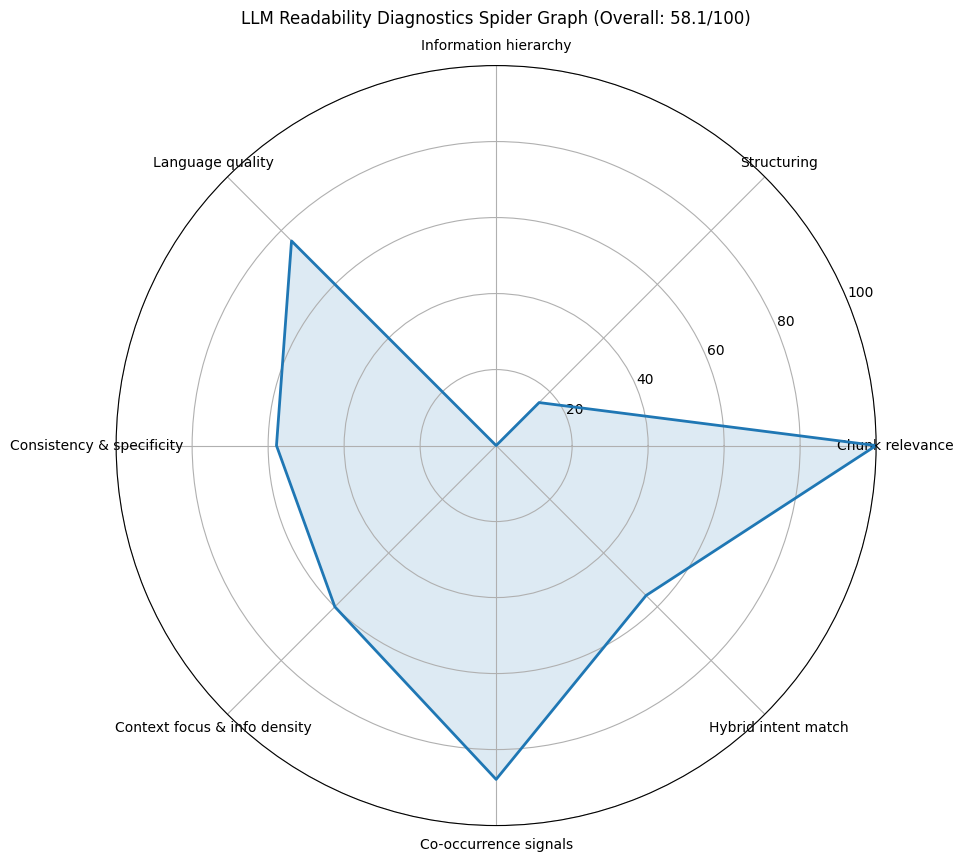


Per-query sparse retrieval coverage (BM25):


,query,best_chunk_id,best_heading,bm25_best_score
4,first pass yield vs rolled througput yield,0,,2.488678
1,what is a good first pass yield percentage,0,,2.283191
0,first pass yield formula,0,,1.872217
2,first pass yield calculator,0,,1.872217
3,first pass yield chart,0,,1.872217



Per-query dense retrieval coverage (embeddings):


,query,best_chunk_id,best_heading,dense_best_similarity
1,what is a good first pass yield percentage,0,,0.473442
4,first pass yield vs rolled througput yield,0,,0.452137
3,first pass yield chart,0,,0.441083
2,first pass yield calculator,0,,0.408300
0,first pass yield formula,0,,0.382445



Top chunk fixes (priority first):


,chunk_id,heading,chunk_chars,first_sentence_chars,answer_in_first_sentence,context_dependency_hits,fix_priority
0,0,,4469,57,False,0,3



Top co-occurring term pairs:


,term_a,term_b,count,pmi
0,first,pass,62,3.059232
1,pass,yield,62,3.474270
2,control,process,57,2.145919
3,first,yield,56,2.912391
4,connected,process,51,2.637531
5,connected,control,43,3.019402
6,process,production,42,1.257887
7,control,solutions,42,2.985454
8,process,solutions,39,2.250508
9,control,production,31,1.447797


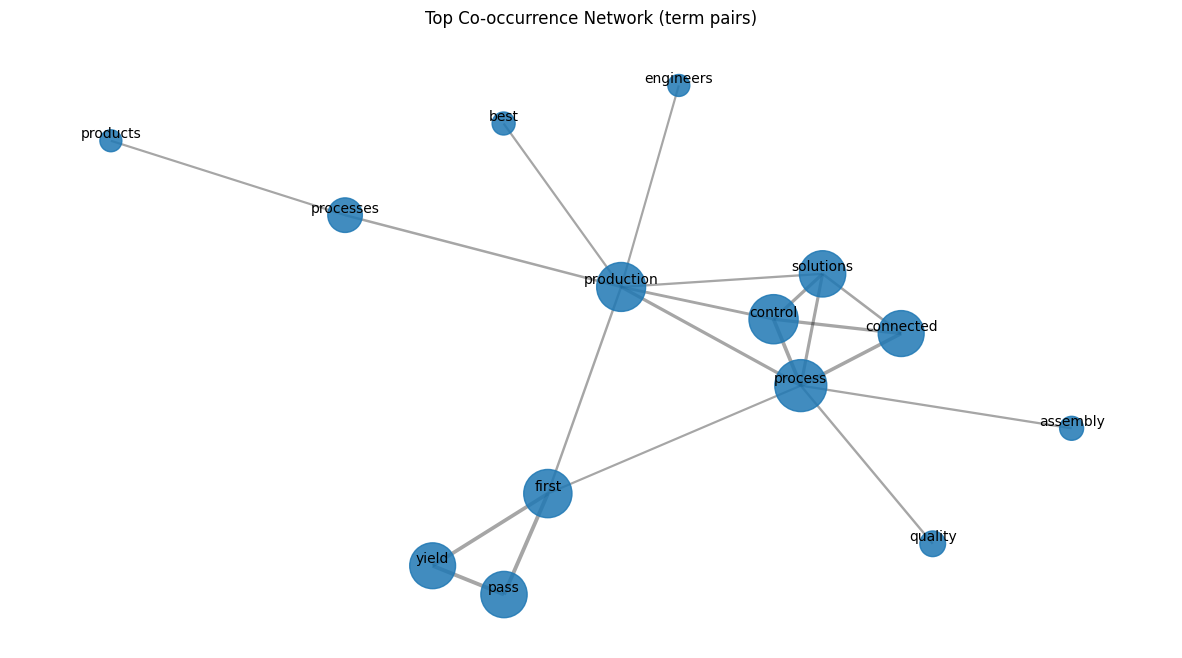

In [ ]:
# =========================
# 10) OUTPUTS
# =========================
print("=" * 80)
print("LLM READABILITY + RAG RETRIEVAL-READINESS AUDIT (v2)")
print("=" * 80)
print(f"Input mode: {INPUT_MODE}")
if INPUT_MODE == "url":
    print(f"URL: {INPUT_URL}")
else:
    print(f"DOCX path: {INPUT_DOCX_PATH}")
print(f"Sections detected: {len(sections)}")
print(f"Chunks built: {len(chunk_df)}")
print(f"Overall score (weighted): {overall:.1f}/100")

scores_df = pd.DataFrame({
    "Diagnostic": list(subscores.keys()),
    "Score": list(subscores.values())
}).sort_values("Score", ascending=False)

print("\nDiagnostic Scores")
display(scores_df)

# Drilldown diagnostics
print("\nContext Focus & Information Density diagnostics:")
for k, v in cfd_diag.items():
    print(f"  - {k}: {v:.3f}" if isinstance(v, (int, float)) else f"  - {k}: {v}")

print("\nCo-occurrence diagnostics:")
for k, v in coocc_diag.items():
    print(f"  - {k}: {v:.3f}" if isinstance(v, (int, float)) else f"  - {k}: {v}")

print("\nSparse retrieval diagnostics (BM25):")
for k, v in sparse_diag.items():
    print(f"  - {k}: {v:.3f}" if isinstance(v, (int, float)) else f"  - {k}: {v}")

print("\nDense retrieval diagnostics (embeddings):")
for k, v in dense_diag.items():
    print(f"  - {k}: {v:.3f}" if isinstance(v, (int, float)) else f"  - {k}: {v}")

print("\nHybrid intent diagnostics:")
for k, v in hybrid_diag.items():
    print(f"  - {k}: {v:.3f}" if isinstance(v, (int, float)) else f"  - {k}: {v}")

# Spider graph
plot_spider_chart(subscores, overall)

# Per-query coverage tables
if len(sparse_per_query_df):
    print("\nPer-query sparse retrieval coverage (BM25):")
    display(sparse_per_query_df.sort_values("bm25_best_score", ascending=False))

if len(dense_per_query_df):
    print("\nPer-query dense retrieval coverage (embeddings):")
    display(dense_per_query_df.sort_values("dense_best_similarity", ascending=False))

# Chunk fix-priority table (helpful for content editing workflow)
if len(chunk_df):
    fix_df = chunk_df.copy()
    fix_df["too_long_chunk"] = fix_df["chunk_chars"] > LONG_SECTION_CHAR_THRESHOLD
    fix_df["fix_priority"] = (
        (~fix_df["answer_in_first_sentence"]).astype(int) * 2
        + (fix_df["context_dependency_hits"] > 0).astype(int) * 2
        + fix_df["too_long_chunk"].astype(int) * 1
    )
    fix_df = fix_df.sort_values(["fix_priority", "chunk_chars"], ascending=[False, False])

    print("\nTop chunk fixes (priority first):")
    display(fix_df[[
        "chunk_id", "heading", "chunk_chars", "first_sentence_chars",
        "answer_in_first_sentence", "context_dependency_hits", "fix_priority"
    ]].head(20))

# Top co-occurrence pairs
print("\nTop co-occurring term pairs:")
display(coocc_top_pairs_df.head(COOC_TOP_K))

# Optional graph
if SHOW_COOCCURRENCE_GRAPH:
    plot_cooccurrence_graph(coocc_graph)

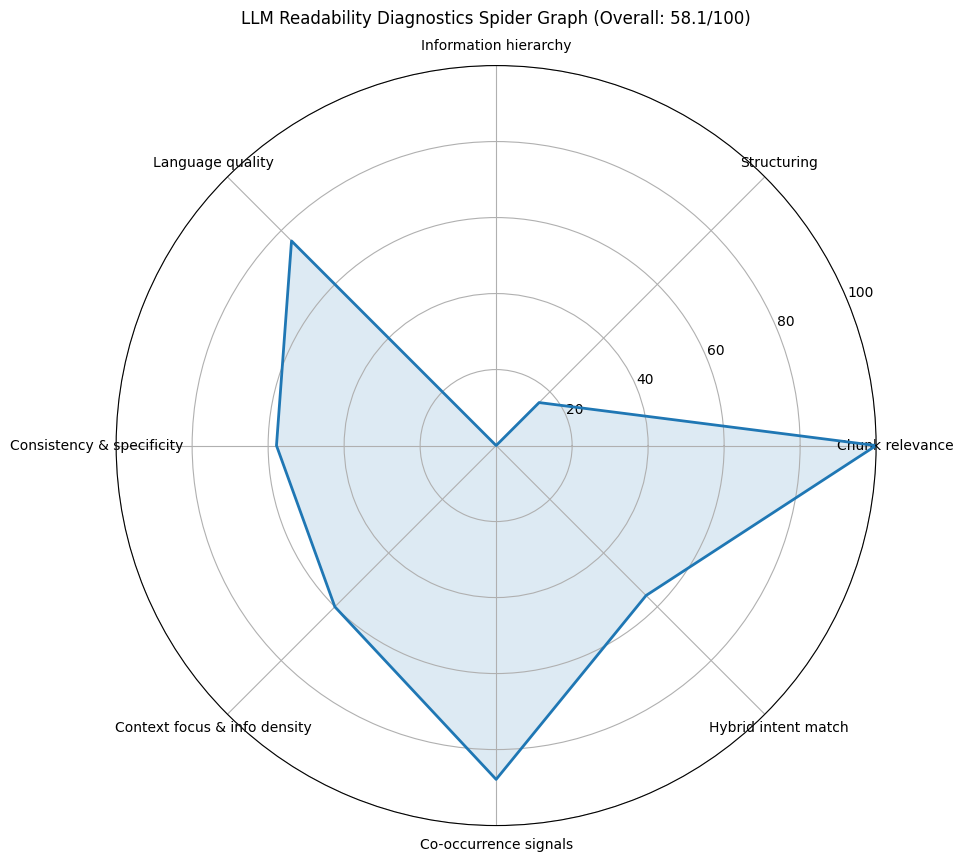

In [ ]:
# Spider graph
plot_spider_chart(subscores, overall)